# 🛒 E-Commerce Product Return Prediction

**Objective:** Build a machine-learning model that predicts whether an
e-commerce order will be returned — enabling businesses to proactively
reduce return-related costs and improve customer satisfaction.

**Dataset:** 12 000 orders × 26 features covering product attributes,
seller metrics, order logistics, and customer behaviour.

**Approach:**
1. Thorough Exploratory Data Analysis (EDA)
2. Data cleaning & feature engineering
3. Scikit-learn `Pipeline` for reproducible preprocessing
4. Cross-validated comparison of four classifiers
5. Hyperparameter tuning with `RandomizedSearchCV`
6. Model saving & deployment via a **Streamlit** web UI

---

## 0 · Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json as json_lib

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_validate, RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report,
                             confusion_matrix, roc_curve, auc)
import joblib

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
print("All libraries imported successfully.")

All libraries imported successfully.


## 1 · Load & Inspect the Dataset

In [8]:
df = pd.read_csv(r"C:\Users\MAHEN\Desktop\ML\Dataset\returns_dataset.csv")
df.head()

,order_id,product_category,sub_category,brand,product_price,discount_percent,product_rating,review_count,fragile_item,warranty_available,...,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,customer_support_calls,chat_interactions,returned
0,ORD100000,Beauty,Haircare,Brand_23,844.10,65.2,2.1,96.0,1,1,...,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,0,0,1
1,ORD100001,Toys,Educational,Brand_9,559.90,30.1,4.1,87.0,0,1,...,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,2,0
2,ORD100002,Electronics,Laptops,Brand_21,1581.93,53.4,3.0,75.0,0,0,...,Marketplace Fulfilled,UPI,3,575.2,1,0,7,0,0,0
3,ORD100003,Electronics,Laptops,Brand_30,1301.55,25.3,3.8,57.0,0,1,...,Marketplace Fulfilled,Credit Card,4,164.5,0,1,9,0,1,0
4,ORD100004,Electronics,Laptops,Brand_15,1402.90,30.6,3.0,71.0,0,1,...,Marketplace Fulfilled,Credit Card,4,474.4,0,0,12,0,0,0


In [9]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset shape: 12,000 rows × 26 columns


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  12000 non-null  str    
 1   product_category          12000 non-null  str    
 2   sub_category              12000 non-null  str    
 3   brand                     12000 non-null  str    
 4   product_price             12000 non-null  float64
 5   discount_percent          12000 non-null  float64
 6   product_rating            11760 non-null  float64
 7   review_count              11880 non-null  float64
 8   fragile_item              12000 non-null  int64  
 9   warranty_available        12000 non-null  int64  
 10  product_return_rate       12000 non-null  float64
 11  category_return_rate      12000 non-null  float64
 12  brand_return_rate         12000 non-null  float64
 13  defect_rate               12000 non-null  float64
 14  seller_rating    

In [11]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
product_price,12000.0,964.063,1678.771,19.510,328.235,597.470,1105.395,64878.670
discount_percent,12000.0,33.567,19.378,0.000,16.800,33.500,50.400,67.000
product_rating,11760.0,3.887,0.636,1.600,3.500,3.900,4.300,5.000
review_count,11880.0,69.437,18.446,24.000,54.000,69.000,85.000,116.000
fragile_item,12000.0,0.197,0.398,0.000,0.000,0.000,0.000,1.000
warranty_available,12000.0,0.446,0.497,0.000,0.000,0.000,1.000,1.000
product_return_rate,12000.0,0.133,0.070,0.001,0.082,0.134,0.183,0.367
category_return_rate,12000.0,0.120,0.050,0.001,0.087,0.120,0.154,0.354
brand_return_rate,12000.0,0.132,0.059,0.010,0.090,0.135,0.176,0.322
defect_rate,12000.0,0.061,0.043,0.000,0.029,0.051,0.082,0.370


## 2 · Exploratory Data Analysis (EDA)

### 2.1 Target Variable Distribution

The target column `returned` is binary: **0** = Not Returned, **1** = Returned.

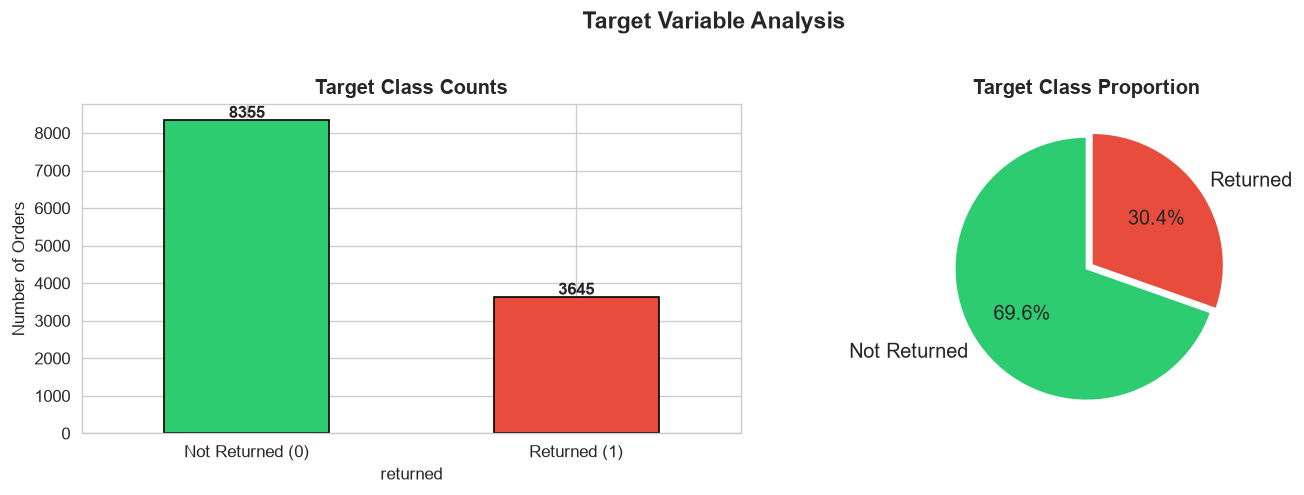


🔹 Class ratio: 2.29 : 1  (Not Returned : Returned)


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df["returned"].value_counts()
counts.plot(kind="bar", ax=axes[0],
            color=["#2ecc71", "#e74c3c"], edgecolor="black")
axes[0].set_xticklabels(["Not Returned (0)", "Returned (1)"], rotation=0)
axes[0].set_title("Target Class Counts", fontweight="bold")
axes[0].set_ylabel("Number of Orders")
for i, v in enumerate(counts):
    axes[0].text(i, v + 50, str(v), ha="center", fontweight="bold")

pcts = (df["returned"].value_counts(normalize=True) * 100).round(1)
axes[1].pie(pcts, labels=["Not Returned", "Returned"],
            autopct="%1.1f%%", colors=["#2ecc71", "#e74c3c"],
            startangle=90, explode=(0, 0.05),
            textprops={"fontsize": 12})
axes[1].set_title("Target Class Proportion", fontweight="bold")

plt.suptitle("Target Variable Analysis",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

print(f"\n🔹 Class ratio: {counts[0]/counts[1]:.2f} : 1  "
      f"(Not Returned : Returned)")

### 2.2 Missing Values

In [13]:
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"Count": missing, "Percentage (%)": missing_pct})
missing_df = missing_df[missing_df["Count"] > 0].sort_values(
    "Count", ascending=False)

if len(missing_df) > 0:
    print("Columns with missing values:\n")
    display(missing_df)

else:
    print("No missing values found.")

Columns with missing values:



,Count,Percentage (%)
product_rating,240,2.0
seller_rating,180,1.5
review_count,120,1.0
shipping_distance_km,120,1.0


### 2.3 Categorical Feature Overview

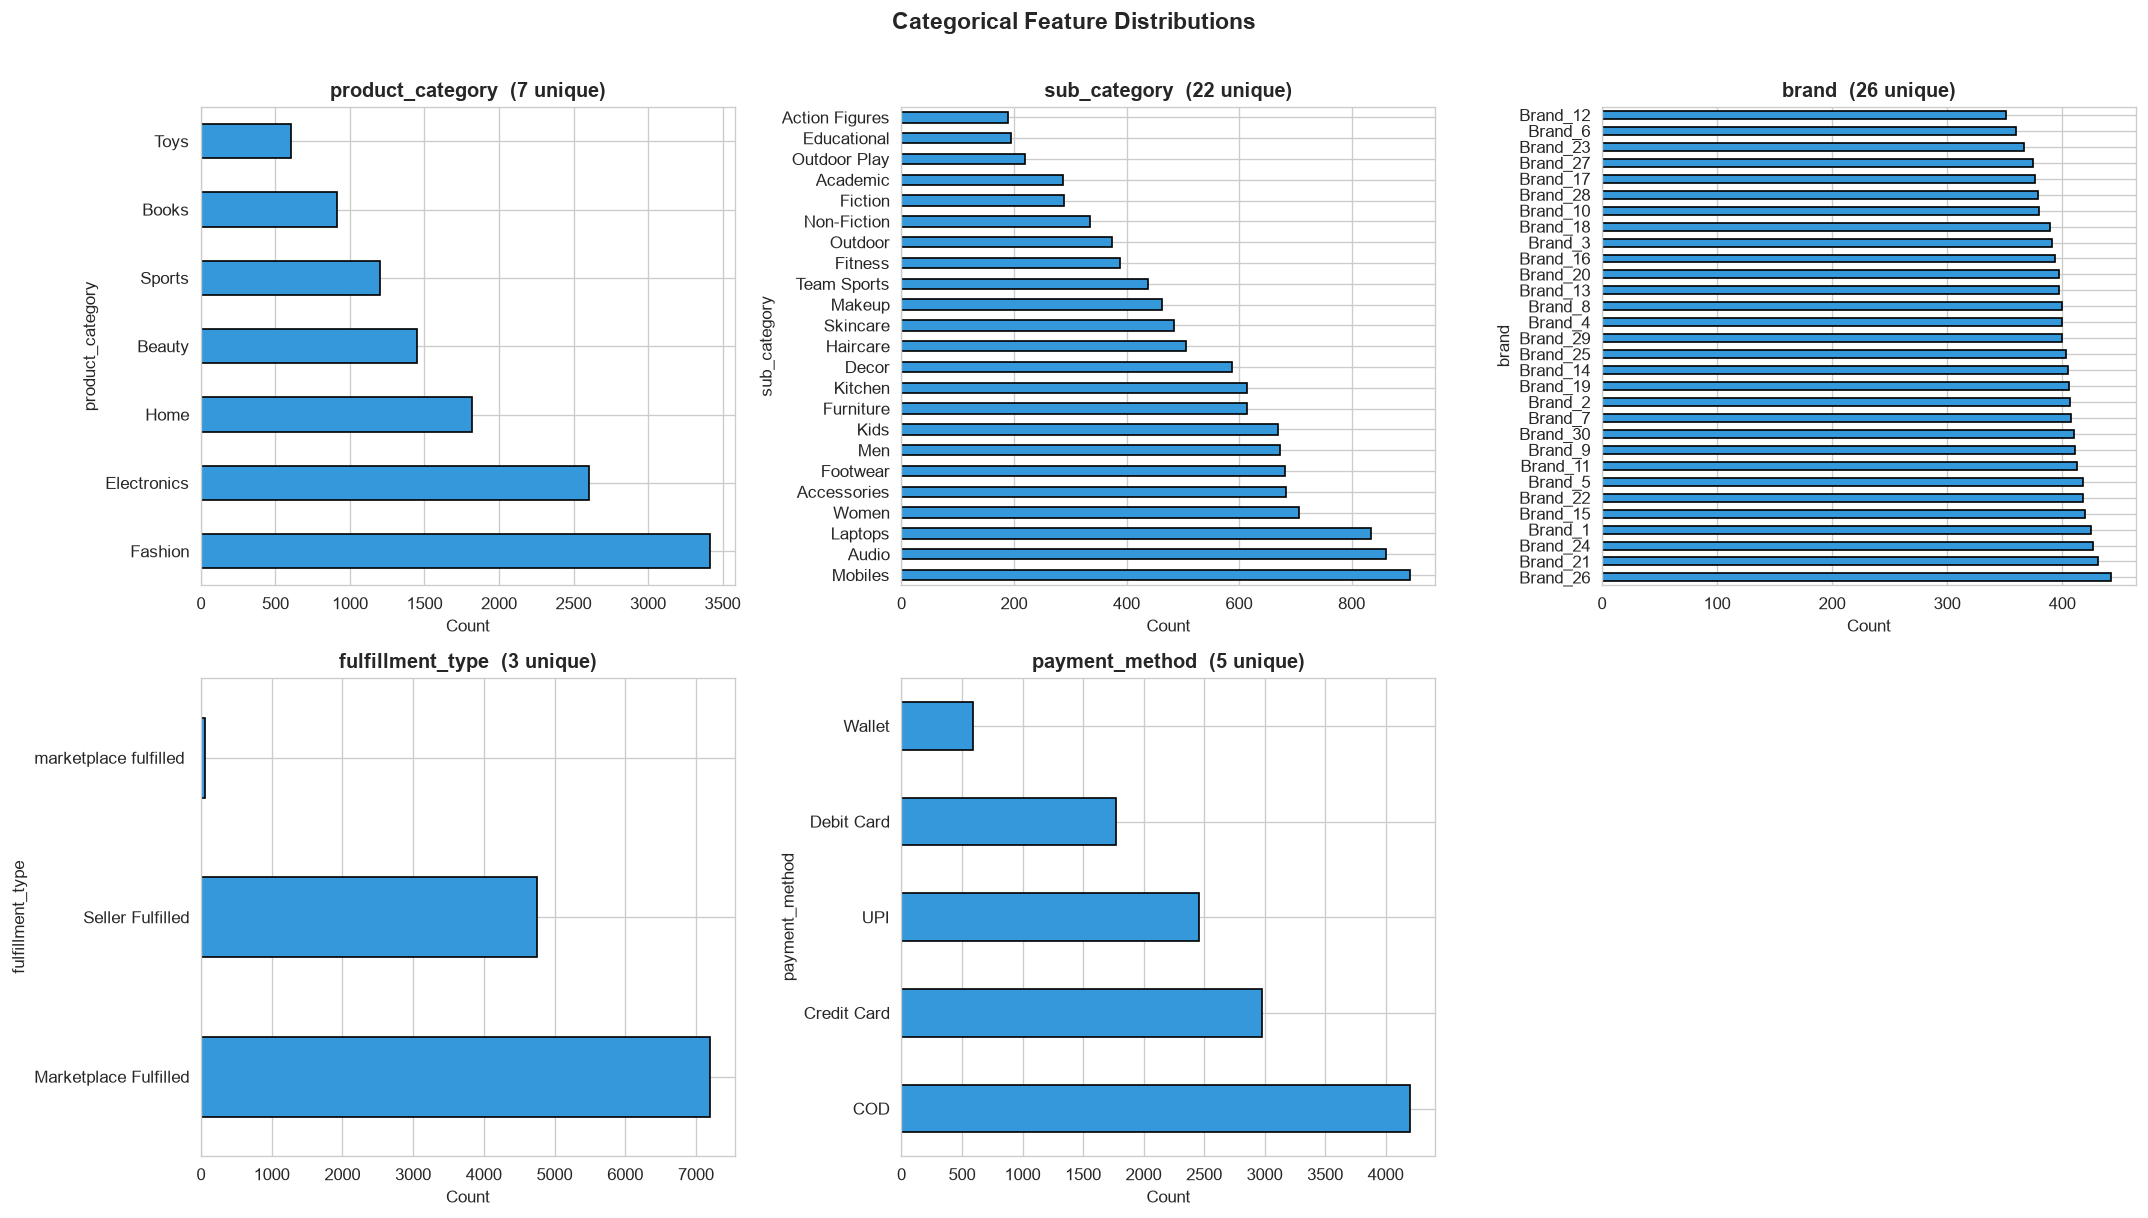

In [14]:
cat_cols_eda = ["product_category", "sub_category", "brand",
                "fulfillment_type", "payment_method"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    vc = df[col].value_counts()
    vc.plot(kind="barh", ax=axes[i], color="#3498db", edgecolor="black")
    axes[i].set_title(f"{col}  ({vc.nunique()} unique)", fontweight="bold")
    axes[i].set_xlabel("Count")

axes[-1].set_visible(False)
plt.suptitle("Categorical Feature Distributions",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

### 2.4 Return Rate by Key Categories

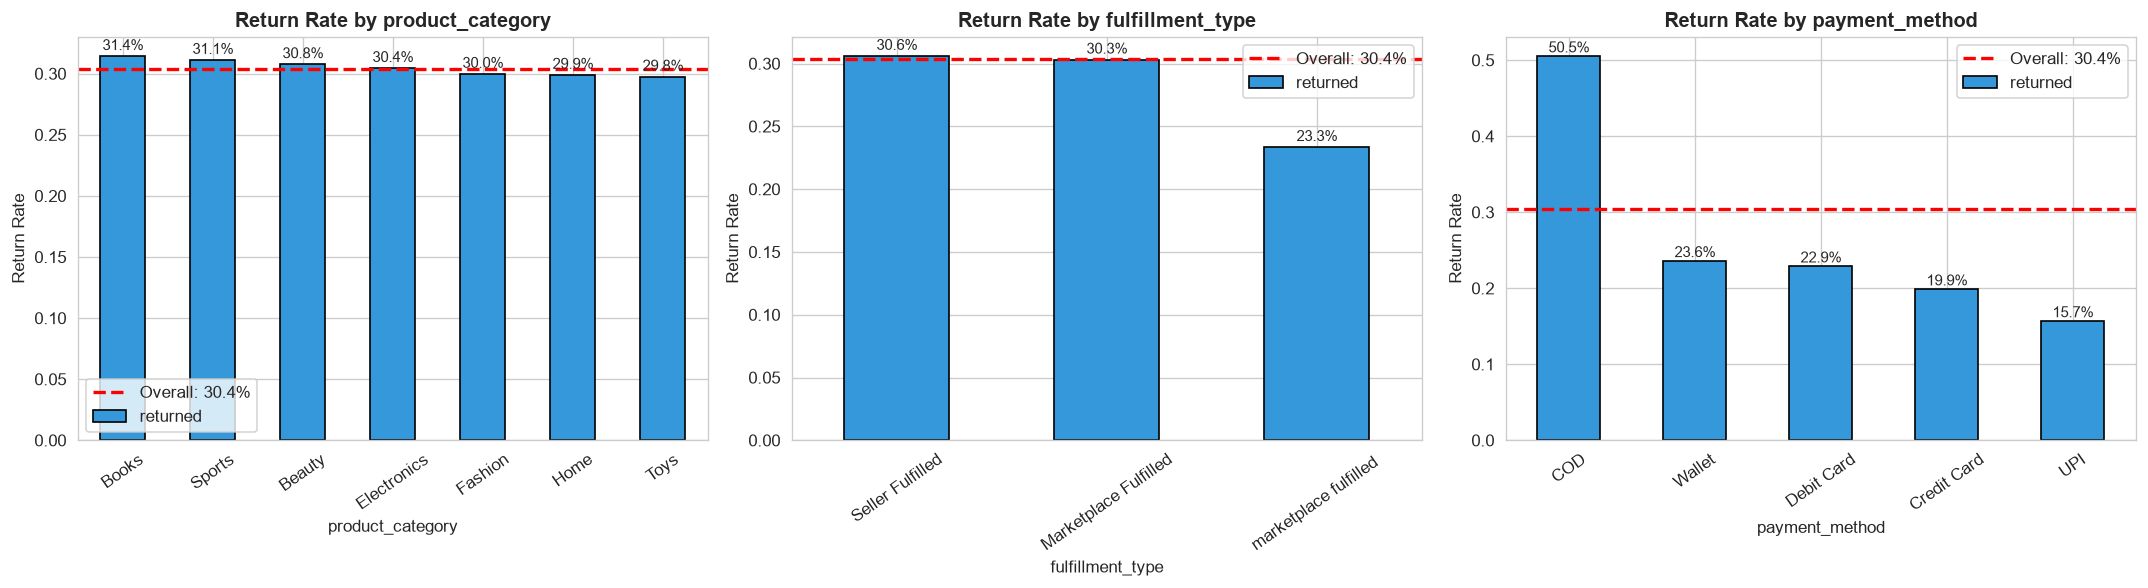

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
overall_rate = df["returned"].mean()

for ax, col in zip(axes,
        ["product_category", "fulfillment_type", "payment_method"]):
    rate = df.groupby(col)["returned"].mean().sort_values(ascending=False)
    bars = rate.plot(kind="bar", ax=ax, color="#3498db", edgecolor="black")
    ax.axhline(overall_rate, ls="--", color="red", lw=2,
               label=f"Overall: {overall_rate:.1%}")
    ax.set_title(f"Return Rate by {col}", fontweight="bold")
    ax.set_ylabel("Return Rate")
    ax.tick_params(axis="x", rotation=35)
    ax.legend()
    for bar in bars.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.1%}", ha="center", fontsize=9)

plt.tight_layout(); plt.show()

### 2.5 Numerical Feature Distributions

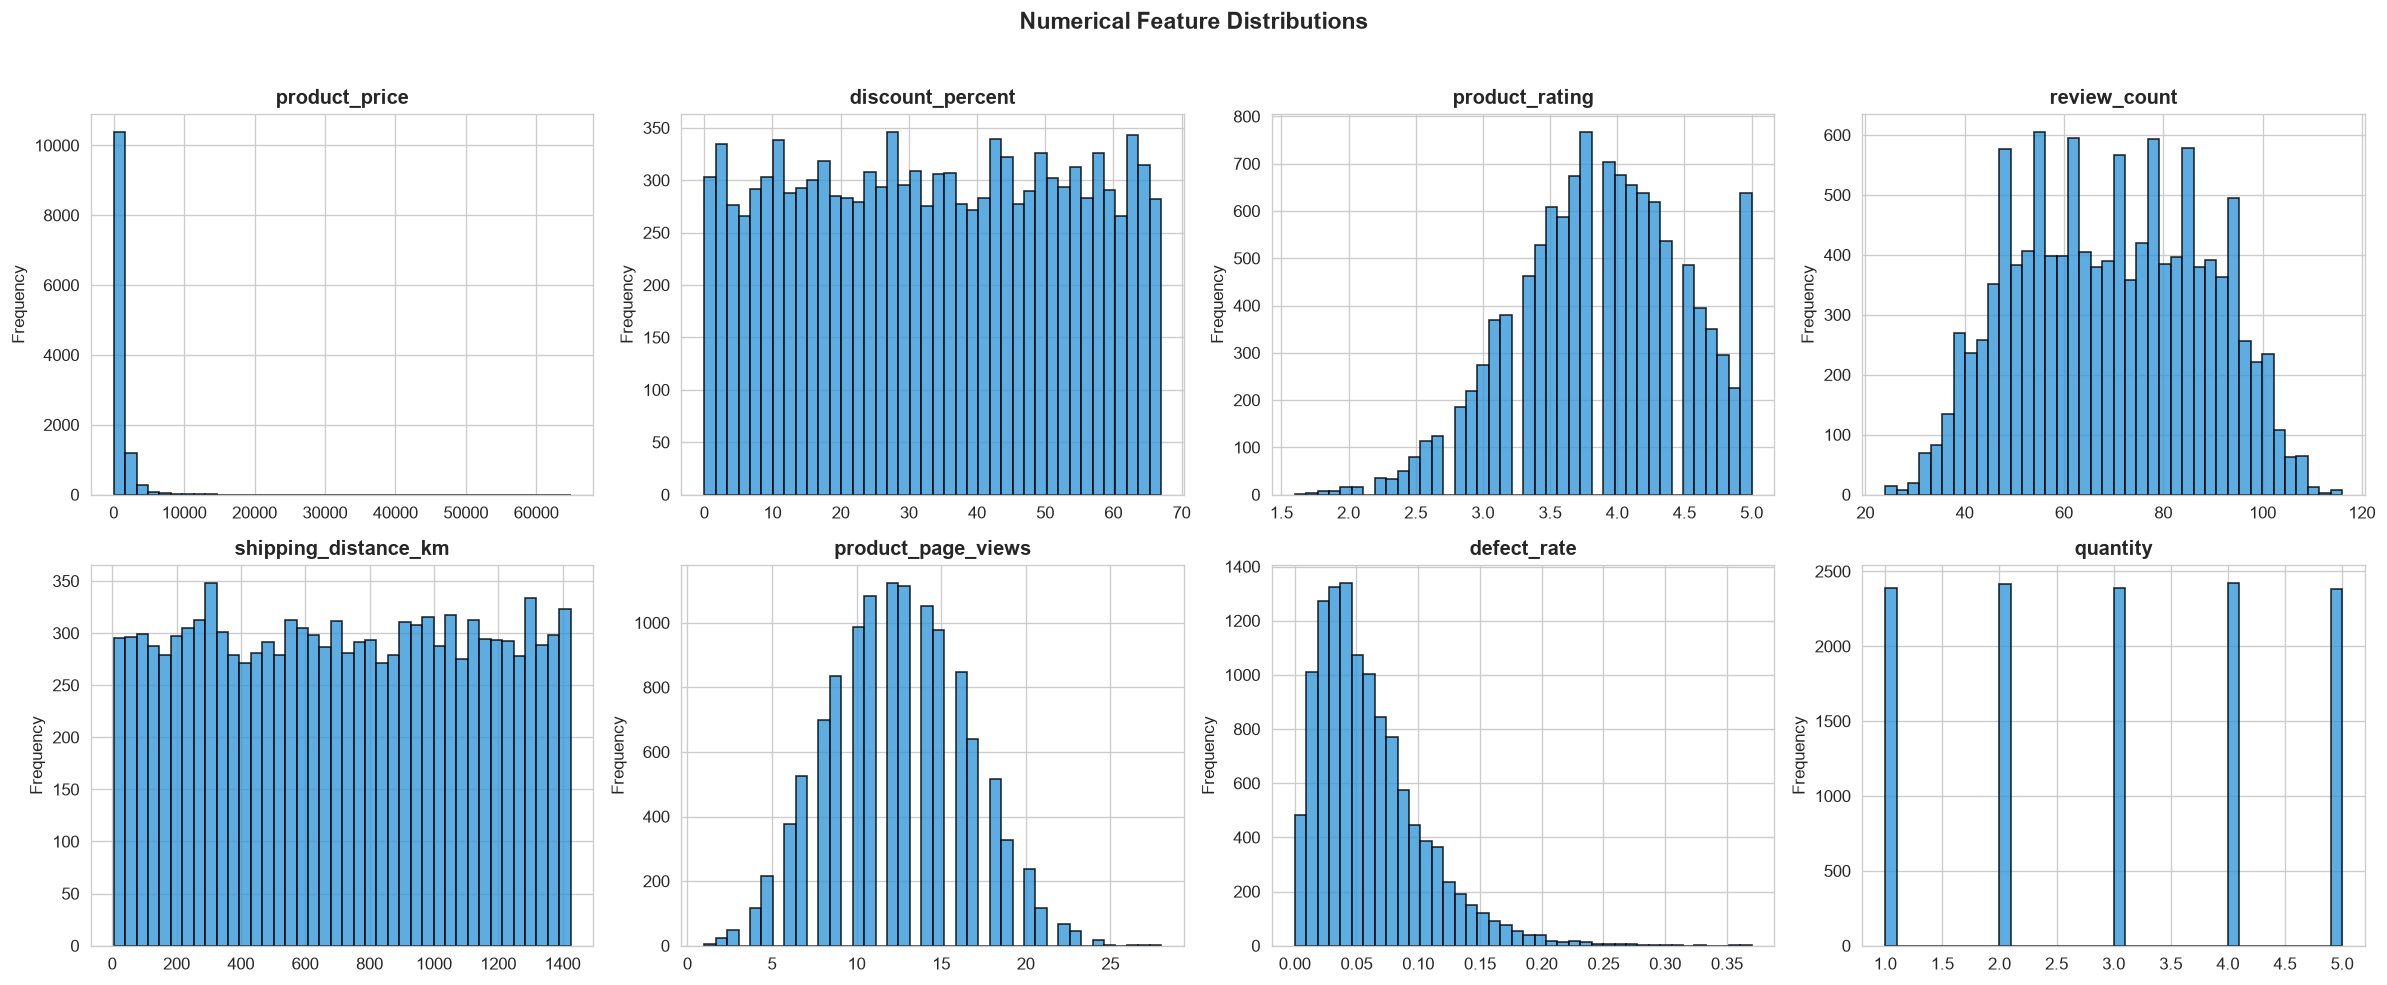

In [16]:
num_feats_eda = [
    "product_price", "discount_percent", "product_rating",
    "review_count", "shipping_distance_km", "product_page_views",
    "defect_rate", "quantity"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for ax, col in zip(axes.flatten(), num_feats_eda):
    ax.hist(df[col].dropna(), bins=40,
            color="#3498db", edgecolor="black", alpha=0.8)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Frequency")

plt.suptitle("Numerical Feature Distributions",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

### 2.6 Correlation Analysis

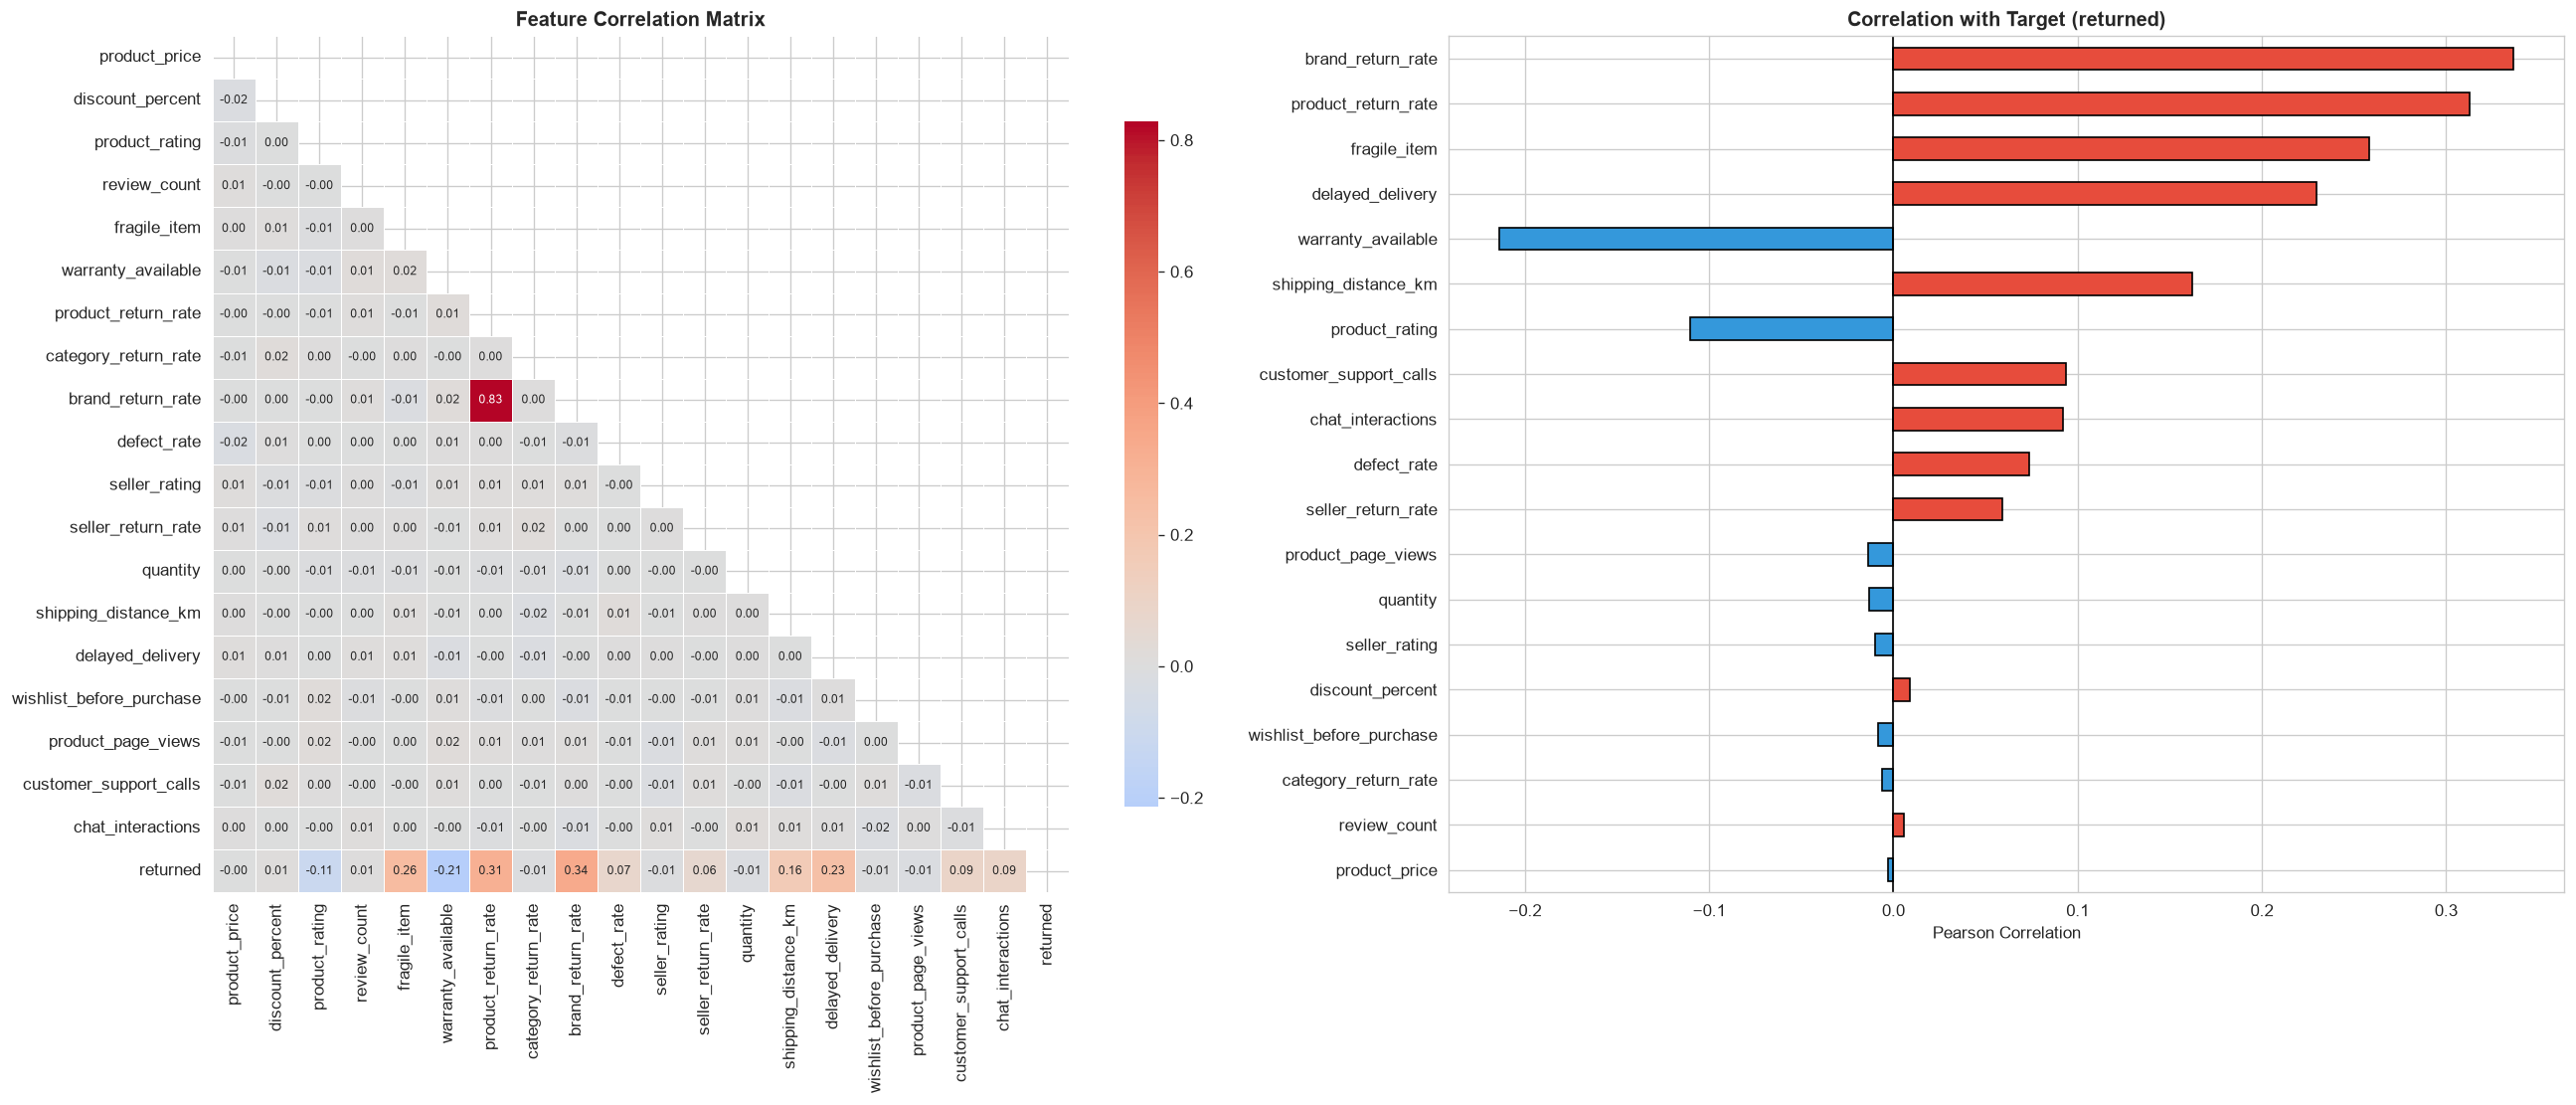

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0, square=True,
            linewidths=0.5, annot=True, fmt=".2f", ax=axes[0],
            cbar_kws={"shrink": 0.8}, annot_kws={"size": 7})
axes[0].set_title("Feature Correlation Matrix", fontweight="bold")

target_corr = (corr["returned"].drop("returned")
               .sort_values(key=abs, ascending=True))
colors = ["#e74c3c" if x > 0 else "#3498db" for x in target_corr]
target_corr.plot(kind="barh", ax=axes[1], color=colors, edgecolor="black")
axes[1].set_title("Correlation with Target (returned)", fontweight="bold")
axes[1].set_xlabel("Pearson Correlation")
axes[1].axvline(0, color="black", lw=1)

plt.tight_layout(); plt.show()

## 3 · Data Cleaning

In [18]:
cleaned_df = df.copy()

print("Before cleaning:")
print(cleaned_df["fulfillment_type"].value_counts())

cleaned_df["fulfillment_type"] = (
    cleaned_df["fulfillment_type"].str.strip().str.title()
)

print("\nAfter cleaning:")
print(cleaned_df["fulfillment_type"].value_counts())

Before cleaning:
fulfillment_type
Marketplace Fulfilled     7193
Seller Fulfilled          4747
marketplace fulfilled       60
Name: count, dtype: int64

After cleaning:
fulfillment_type
Marketplace Fulfilled    7253
Seller Fulfilled         4747
Name: count, dtype: int64


In [19]:
dup_count = cleaned_df.duplicated().sum()
print(f"Duplicate rows: {dup_count}")
if dup_count > 0:
    cleaned_df = cleaned_df.drop_duplicates()
    print(f"Removed {dup_count} duplicates. New shape: {cleaned_df.shape}")
else:
    print("No duplicates found.")

Duplicate rows: 0
No duplicates found.


In [20]:
cleaned_df = cleaned_df.drop(columns=["order_id"])
print(f"Dropped 'order_id'. Remaining columns: {cleaned_df.shape[1]}")

Dropped 'order_id'. Remaining columns: 25


## 4 · Feature Engineering

### 4.1 Log-Transform Product Price to fix the right skewed

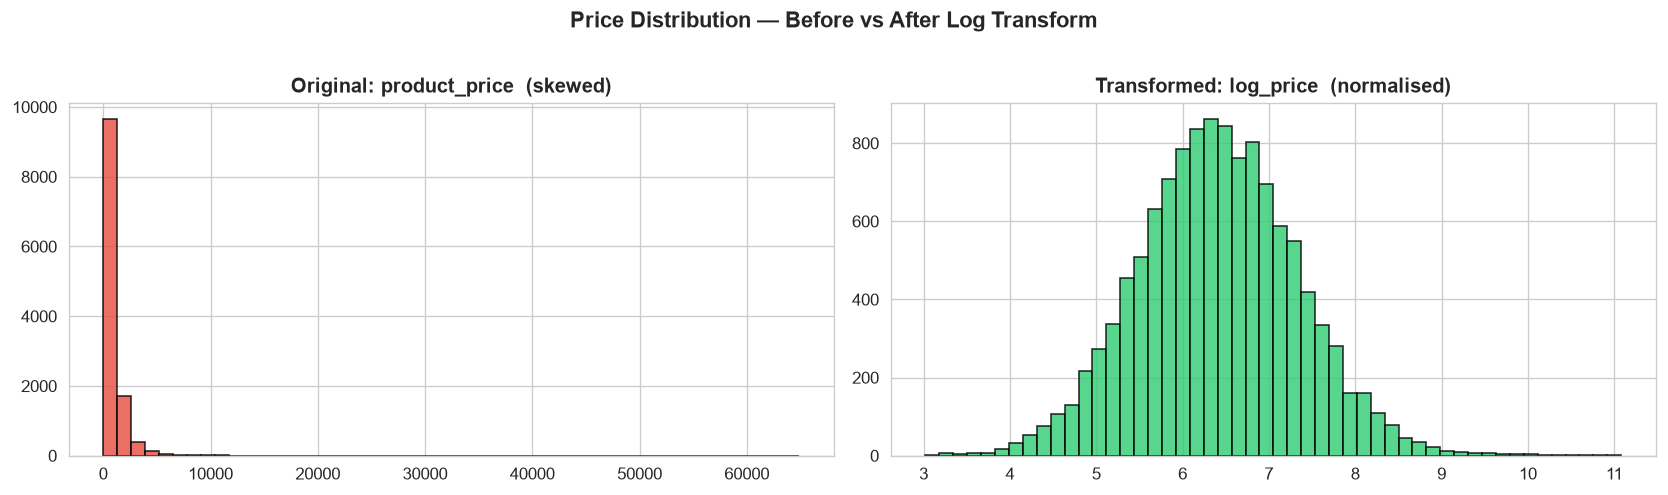

Replaced 'product_price' with 'log_price'.


In [21]:
cleaned_df["log_price"] = np.log1p(cleaned_df["product_price"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(cleaned_df["product_price"], bins=50,
             color="#e74c3c", edgecolor="black", alpha=0.8)
axes[0].set_title("Original: product_price  (skewed)", fontweight="bold")

axes[1].hist(cleaned_df["log_price"], bins=50,
             color="#2ecc71", edgecolor="black", alpha=0.8)
axes[1].set_title("Transformed: log_price  (normalised)", fontweight="bold")

plt.suptitle("Price Distribution — Before vs After Log Transform",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

cleaned_df = cleaned_df.drop(columns=["product_price"])
print("Replaced 'product_price' with 'log_price'.")

### 4.2 Combine Support-Contact Features

`customer_support_calls` and `chat_interactions` are both low-count
features. Combining them into a single `total_support_contacts` reduces
dimensionality while preserving the signal.

In [22]:
cleaned_df["total_support_contacts"] = (
    cleaned_df["customer_support_calls"]
    + cleaned_df["chat_interactions"]
)
cleaned_df = cleaned_df.drop(
    columns=["customer_support_calls", "chat_interactions"])
print("Created 'total_support_contacts', dropped original columns.")

Created 'total_support_contacts', dropped original columns.


In [23]:
leakage_features = [
    "product_return_rate", "category_return_rate",
    "brand_return_rate",   "seller_return_rate",
]

cleaned_df = cleaned_df.drop(columns=leakage_features)
print(f"Dropped {len(leakage_features)} leakage features: "
      f"{leakage_features}")
print(f"   Remaining columns: {cleaned_df.shape[1]}")

Dropped 4 leakage features: ['product_return_rate', 'category_return_rate', 'brand_return_rate', 'seller_return_rate']
   Remaining columns: 20


In [24]:
print(f"Cleaned dataset: {cleaned_df.shape[0]:,} rows "
      f"× {cleaned_df.shape[1]} columns\n")
print("Columns:", list(cleaned_df.columns))
cleaned_df.head()

Cleaned dataset: 12,000 rows × 20 columns

Columns: ['product_category', 'sub_category', 'brand', 'discount_percent', 'product_rating', 'review_count', 'fragile_item', 'warranty_available', 'defect_rate', 'seller_rating', 'fulfillment_type', 'payment_method', 'quantity', 'shipping_distance_km', 'delayed_delivery', 'wishlist_before_purchase', 'product_page_views', 'returned', 'log_price', 'total_support_contacts']


,product_category,sub_category,brand,discount_percent,product_rating,review_count,fragile_item,warranty_available,defect_rate,seller_rating,fulfillment_type,payment_method,quantity,shipping_distance_km,delayed_delivery,wishlist_before_purchase,product_page_views,returned,log_price,total_support_contacts
0,Beauty,Haircare,Brand_23,65.2,2.1,96.0,1,1,0.116,4.1,Marketplace Fulfilled,Credit Card,5,187.9,0,0,9,1,6.739455,0
1,Toys,Educational,Brand_9,30.1,4.1,87.0,0,1,0.031,4.2,Marketplace Fulfilled,Credit Card,2,1281.9,0,0,14,0,6.329543,2
2,Electronics,Laptops,Brand_21,53.4,3.0,75.0,0,0,0.057,4.1,Marketplace Fulfilled,UPI,3,575.2,1,0,7,0,7.367033,0
3,Electronics,Laptops,Brand_30,25.3,3.8,57.0,0,1,0.064,3.9,Marketplace Fulfilled,Credit Card,4,164.5,0,1,9,0,7.172079,1
4,Electronics,Laptops,Brand_15,30.6,3.0,71.0,0,1,0.076,4.6,Marketplace Fulfilled,Credit Card,4,474.4,0,0,12,0,7.247009,0


## 5 · Train–Test Split

Using an **80 / 20 stratified split** to maintain the same class ratio
in both sets.

In [25]:
X = cleaned_df.drop(columns=["returned"])
y = cleaned_df["returned"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]:,} samples "
      f"({y_train.mean():.1%} positive)")
print(f"Test:  {X_test.shape[0]:,} samples "
      f"({y_test.mean():.1%} positive)")

Train: 9,600 samples (30.4% positive)
Test:  2,400 samples (30.4% positive)


In [26]:
numerical_cols = [
    "discount_percent", "product_rating", "review_count",
    "defect_rate", "seller_rating", "quantity",
    "shipping_distance_km", "product_page_views",
    "total_support_contacts", "log_price",
]

categorical_cols = [
    "product_category", "sub_category", "brand",
    "fulfillment_type", "payment_method",
]

binary_cols = [
    "fragile_item", "warranty_available",
    "delayed_delivery", "wishlist_before_purchase",
]

print(f"Numerical:   {len(numerical_cols)} features")
print(f"Categorical: {len(categorical_cols)} features")
print(f"Binary:      {len(binary_cols)} features")
print(f"Total:       "
      f"{len(numerical_cols)+len(categorical_cols)+len(binary_cols)} "
      f"features")

Numerical:   10 features
Categorical: 5 features
Binary:      4 features
Total:       19 features


Columns Transformer


In [27]:
def make_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    cat_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore",
                                  sparse_output=False)),
    ])
    return ColumnTransformer([
        ("num", num_pipe,    numerical_cols),
        ("cat", cat_pipe,    categorical_cols),
        ("bin", "passthrough", binary_cols),
    ])


def make_pipeline(classifier):
    return Pipeline([
        ("preprocessor", make_preprocessor()),
        ("classifier",   classifier),
    ])

## 7 · Model Comparison — 5-Fold Cross-Validation

Comparing four classifiers using **stratified 5-fold CV** for reliable,
unbiased performance estimates.  All class-imbalance handling is built
into each estimator.

In [28]:
# class-imbalance weight for XGBoost
spw = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": make_pipeline(
        LogisticRegression(max_iter=1000,
                           class_weight="balanced",
                           random_state=42)),
    "Decision Tree": make_pipeline(
        DecisionTreeClassifier(class_weight="balanced",
                               random_state=42)),
    "Random Forest": make_pipeline(
        RandomForestClassifier(n_estimators=300,
                               class_weight="balanced",
                               n_jobs=-1, random_state=42)),
    "XGBoost": make_pipeline(
        XGBClassifier(n_estimators=300, learning_rate=0.1,
                      max_depth=5, scale_pos_weight=spw,
                      eval_metric="logloss",
                      n_jobs=-1, random_state=42)),
}

print(f"Models to compare: {list(models.keys())}")

Models to compare: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost']


In [29]:
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, pipe in models.items():
    print(f"Cross-validating {name} …", end=" ")
    cv_res = cross_validate(pipe, X_train, y_train,
                            cv=cv, scoring=scoring, n_jobs=-1)
    results[name] = {m: cv_res[f"test_{m}"].mean() for m in scoring}
    results[name].update(
        {f"{m}_std": cv_res[f"test_{m}"].std() for m in scoring})
    print(f"F1 = {results[name]['f1']:.4f} "
          f"(±{results[name]['f1_std']:.4f})")

print("\n All models cross-validated.")

Cross-validating Logistic Regression … 

F1 = 0.7705 (±0.0065)
Cross-validating Decision Tree … F1 = 0.6051 (±0.0156)
Cross-validating Random Forest … F1 = 0.7311 (±0.0098)
Cross-validating XGBoost … F1 = 0.7472 (±0.0061)

 All models cross-validated.


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.8461 ± 0.0044,0.7044 ± 0.0064,0.8505 ± 0.0073,0.7705 ± 0.0065,0.9294 ± 0.0029
XGBoost,0.8376 ± 0.0033,0.7087 ± 0.0066,0.7905 ± 0.0138,0.7472 ± 0.0061,0.9140 ± 0.0038
Random Forest,0.8373 ± 0.0055,0.7339 ± 0.0084,0.7284 ± 0.0134,0.7311 ± 0.0098,0.8990 ± 0.0028
Decision Tree,0.7564 ± 0.0082,0.5960 ± 0.0134,0.6149 ± 0.0229,0.6051 ± 0.0156,0.7165 ± 0.0112


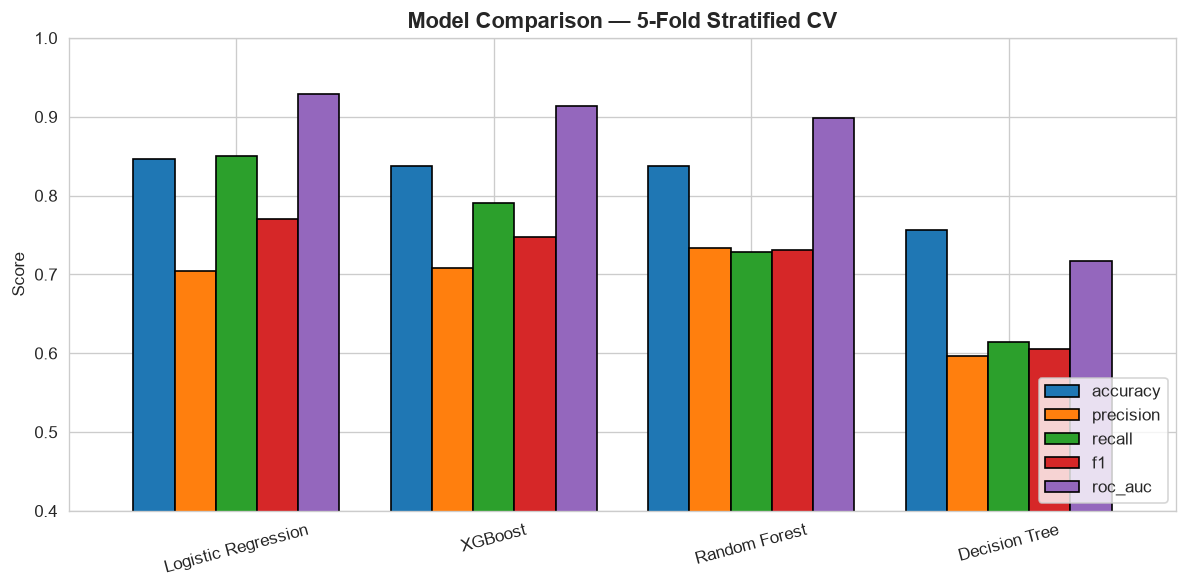


🏆 Best baseline by CV F1: Logistic Regression (F1 = 0.7705)

All baseline models fitted on full training set.


In [32]:
# --- comparison table ---
comp_display = pd.DataFrame({
    name: {m: f"{results[name][m]:.4f} \u00b1 {results[name][m+'_std']:.4f}"
           for m in scoring}
    for name in results}).T

comp_numeric = pd.DataFrame({
    name: {m: results[name][m] for m in scoring}
    for name in results}).T.sort_values("f1", ascending=False)

display(comp_display.loc[comp_numeric.index])

# --- bar chart ---
fig, ax = plt.subplots(figsize=(10, 5))
comp_numeric[scoring].plot(kind="bar", ax=ax,
                           edgecolor="black", width=0.8)
ax.set_title("Model Comparison \u2014 5-Fold Stratified CV",
             fontweight="bold", fontsize=13)
ax.set_ylabel("Score"); ax.set_ylim(0.4, 1.0)
ax.legend(loc="lower right")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

best_baseline = comp_numeric["f1"].idxmax()
print(f"\n\U0001f3c6 Best baseline by CV F1: {best_baseline} "
      f"(F1 = {comp_numeric.loc[best_baseline, 'f1']:.4f})")

# Fit ALL baseline models on the full training set
# so we can compare them with tuned XGBoost on the test set later
fitted_baselines = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    fitted_baselines[name] = pipe
print("\nAll baseline models fitted on full training set.")


In [33]:
xgb_pipe = make_pipeline(
    XGBClassifier(scale_pos_weight=spw, eval_metric="logloss",
                  n_jobs=-1, random_state=42)
)

param_dist = {
    "classifier__n_estimators":    [100, 200, 300, 400, 500, 600],
    "classifier__max_depth":       [3, 4, 5, 6, 7, 8],
    "classifier__learning_rate":   [0.01, 0.03, 0.05, 0.1, 0.15],
    "classifier__subsample":       [0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree":[0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__min_child_weight":[1, 3, 5, 7],
    "classifier__gamma":           [0, 0.05, 0.1, 0.2, 0.3],
    "classifier__reg_alpha":       [0, 0.01, 0.1, 0.5, 1.0],
    "classifier__reg_lambda":      [0.5, 1.0, 1.5, 2.0, 3.0],
}

search = RandomizedSearchCV(
    xgb_pipe, param_dist,
    n_iter=50, scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42, n_jobs=-1, verbose=1,
    return_train_score=True,
)

print("Running RandomizedSearchCV "
      "(50 iterations × 5 folds = 250 fits) …\n")
search.fit(X_train, y_train)
print(f"\nBest CV F1: {search.best_score_:.4f}")

Running RandomizedSearchCV (50 iterations × 5 folds = 250 fits) …

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best CV F1: 0.7638


In [34]:
print("Best Hyperparameters:\n")
for param, value in sorted(search.best_params_.items()):
    print(f"{param.replace('classifier__', ''):25s} {value}")

Best Hyperparameters:

colsample_bytree          0.9
gamma                     0.1
learning_rate             0.05
max_depth                 4
min_child_weight          3
n_estimators              300
reg_alpha                 0
reg_lambda                1.0
subsample                 0.7


## 9 Final Model Evaluation

Comparing the **tuned XGBoost** against all baseline models on the
held-out test set, then selecting the **overall winner** for deployment.

In [35]:
candidates = {"Tuned XGBoost": search.best_estimator_}
candidates.update(fitted_baselines)

print("=" * 62)
print("  MODEL COMPARISON ON HELD-OUT TEST SET")
print("=" * 62)

test_scores = {}
for name, pipe in candidates.items():
    yp = pipe.predict(X_test)
    sc = {
        "Accuracy":  accuracy_score(y_test, yp),
        "Precision": precision_score(y_test, yp),
        "Recall":    recall_score(y_test, yp),
        "F1":        f1_score(y_test, yp),
    }
    test_scores[name] = sc
    print(f"  {name:25s}  Acc={sc['Accuracy']:.4f}  "
          f"Prec={sc['Precision']:.4f}  Rec={sc['Recall']:.4f}  "
          f"F1={sc['F1']:.4f}")

print("=" * 62)

# Pick the winner by F1 score
final_model_name = max(test_scores, key=lambda k: test_scores[k]["F1"])
final_pipeline   = candidates[final_model_name]

y_pred  = final_pipeline.predict(X_test)
y_proba = final_pipeline.predict_proba(X_test)[:, 1]
fpr_val, tpr_val, _ = roc_curve(y_test, y_proba)
roc_auc_val = auc(fpr_val, tpr_val)

print(f"\n\U0001f3c6 WINNER: {final_model_name}  "
      f"(F1 = {test_scores[final_model_name]['F1']:.4f}, "
      f"AUC = {roc_auc_val:.4f})")
print("\n\u2192 This model will be used for final evaluation "
      "and deployment.")


  MODEL COMPARISON ON HELD-OUT TEST SET
  Tuned XGBoost              Acc=0.8383  Prec=0.6901  Rec=0.8491  F1=0.7614
  Logistic Regression        Acc=0.8517  Prec=0.7093  Rec=0.8669  F1=0.7802
  Decision Tree              Acc=0.7696  Prec=0.6186  Rec=0.6296  F1=0.6241
  Random Forest              Acc=0.8363  Prec=0.7165  Rec=0.7627  F1=0.7389
  XGBoost                    Acc=0.8367  Prec=0.7008  Rec=0.8066  F1=0.7500

🏆 WINNER: Logistic Regression  (F1 = 0.7802, AUC = 0.9302)

→ This model will be used for final evaluation and deployment.


In [36]:
print(classification_report(
    y_test, y_pred,
    target_names=["Not Returned", "Returned"], digits=4))

              precision    recall  f1-score   support

Not Returned     0.9357    0.8450    0.8881      1671
    Returned     0.7093    0.8669    0.7802       729

    accuracy                         0.8517      2400
   macro avg     0.8225    0.8560    0.8341      2400
weighted avg     0.8669    0.8517    0.8553      2400



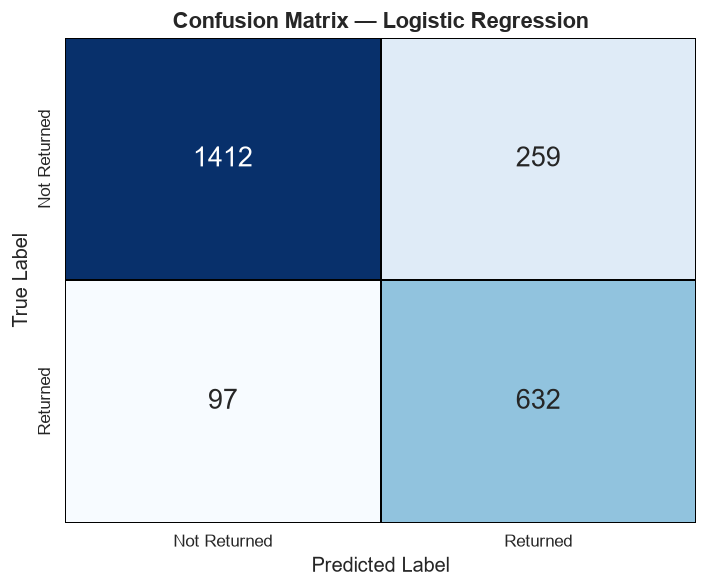

True Negatives:   1412  (correctly predicted Not Returned)
False Positives:   259  (incorrectly predicted Returned)
False Negatives:    97  (missed returns)
True Positives:    632  (correctly predicted Returned)


In [37]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Returned", "Returned"],
            yticklabels=["Not Returned", "Returned"],
            annot_kws={"size": 16},
            linewidths=1, linecolor="black", ax=ax)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title(f"Confusion Matrix — {final_model_name}",
             fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:>5d}  (correctly predicted Not Returned)")
print(f"False Positives: {fp:>5d}  (incorrectly predicted Returned)")
print(f"False Negatives: {fn:>5d}  (missed returns)")
print(f"True Positives:  {tp:>5d}  (correctly predicted Returned)")

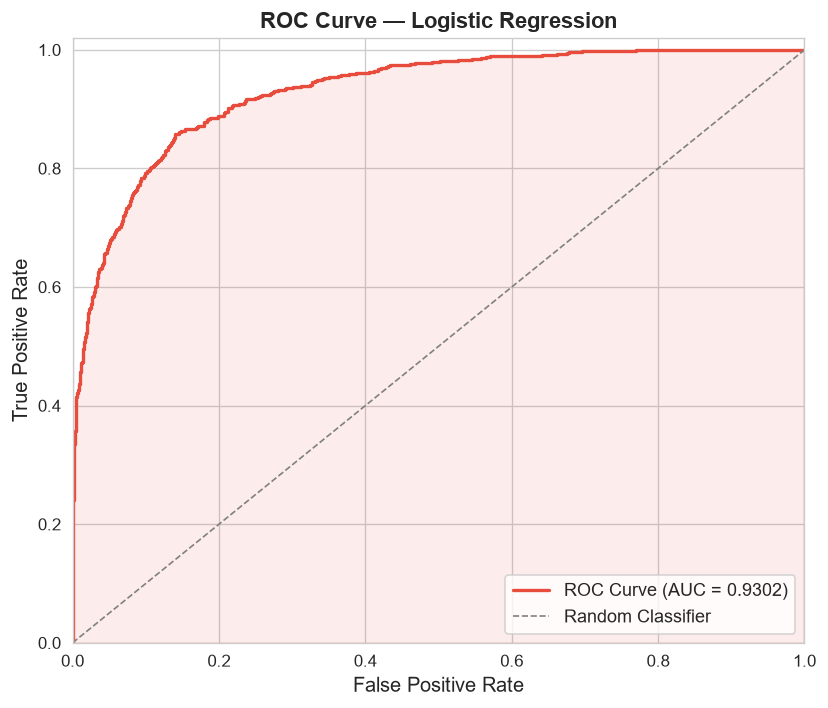

In [38]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_val, tpr_val, color="#e74c3c", lw=2,
        label=f"ROC Curve (AUC = {roc_auc_val:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, ls="--",
        label="Random Classifier")
ax.fill_between(fpr_val, tpr_val, alpha=0.1, color="#e74c3c")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title(f"ROC Curve — {final_model_name}",
             fontweight="bold", fontsize=13)
ax.legend(loc="lower right", fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout(); plt.show()

### Feature Importance Top 20

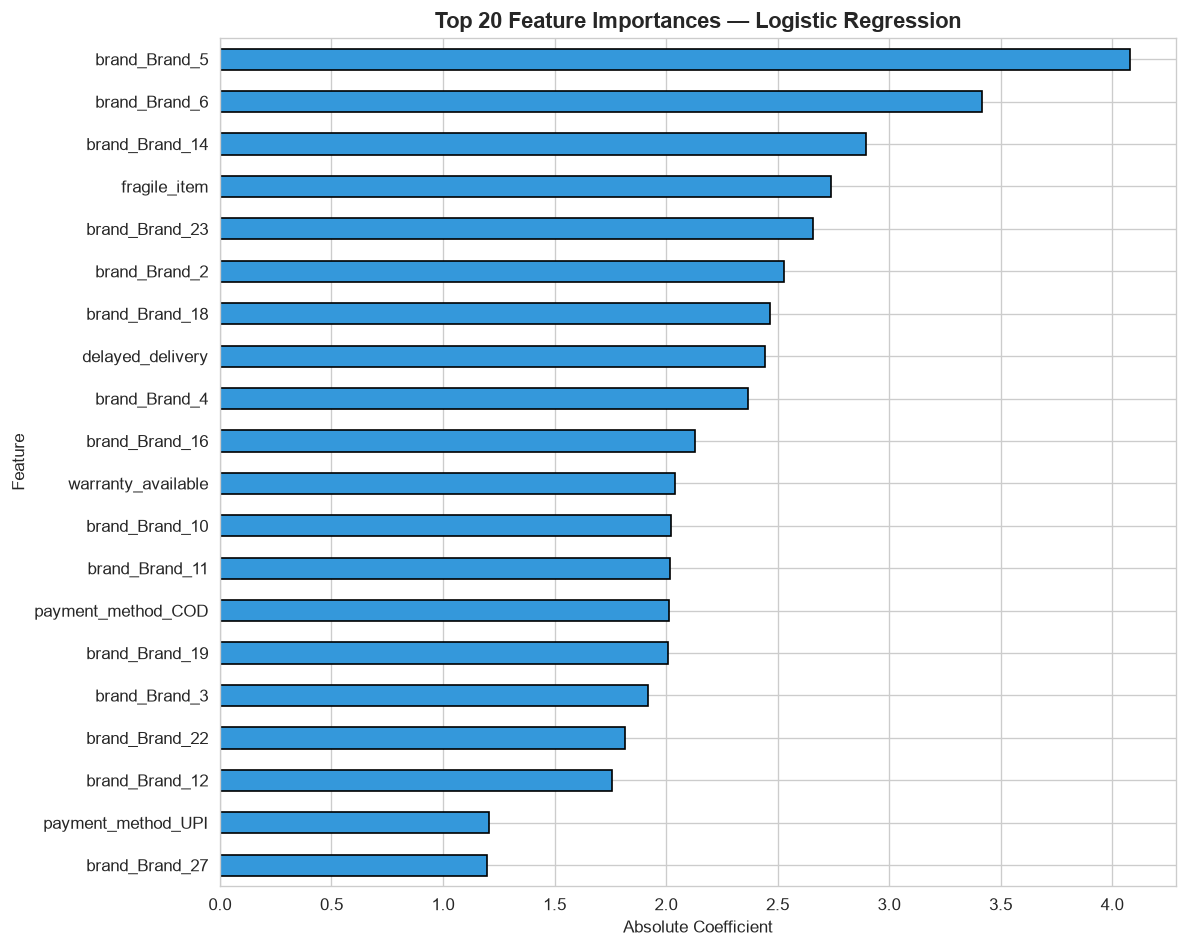

In [39]:
# Extract feature names from the ColumnTransformer
feat_names = final_pipeline.named_steps["preprocessor"] \
                           .get_feature_names_out()
feat_names = [n.replace("num__", "").replace("cat__", "")
               .replace("bin__", "") for n in feat_names]

classifier = final_pipeline.named_steps["classifier"]

# Tree-based models have feature_importances_; linear models have coef_
if hasattr(classifier, "feature_importances_"):
    importances = classifier.feature_importances_
    imp_label = "Importance Score"
elif hasattr(classifier, "coef_"):
    importances = np.abs(classifier.coef_[0])
    imp_label = "Absolute Coefficient"
else:
    importances = np.zeros(len(feat_names))
    imp_label = "N/A"

feat_imp = (pd.DataFrame({"Feature": feat_names,
                           "Importance": importances})
              .sort_values("Importance", ascending=False))

top_n = 20
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.head(top_n).sort_values("Importance").plot(
    kind="barh", x="Feature", y="Importance", ax=ax,
    color="#3498db", edgecolor="black", legend=False)
ax.set_title(f"Top {top_n} Feature Importances \u2014 {final_model_name}",
             fontweight="bold", fontsize=13)
ax.set_xlabel(imp_label)
plt.tight_layout(); plt.show()

## 10 · Save Model for Deployment

Saving the **complete pipeline** (preprocessor + tuned classifier) as a
single file using `joblib`. The deployed model handles imputation,
scaling, encoding, and prediction — all in one call.

In [40]:
os.makedirs("model", exist_ok=True)

# --- save pipeline ---
model_path = "model/return_predictor.joblib"
joblib.dump(final_pipeline, model_path)
print(f"✅ Model saved to: {model_path}")
print(f"   File size: {os.path.getsize(model_path) / 1024:.1f} KB")

# --- save metadata for the Streamlit UI ---
metadata = {
    "features": {
        "numerical":   numerical_cols,
        "categorical": categorical_cols,
        "binary":      binary_cols,
    },
    "categorical_options": {
        col: sorted(df[col].astype(str).str.strip().str.title()
                    .unique().tolist())
        for col in categorical_cols
    },
    "numerical_ranges": {
        col: {"min": round(float(X_train[col].min()), 2),
              "max": round(float(X_train[col].max()), 2),
              "median": round(float(X_train[col].median()), 2)}
        for col in numerical_cols
    },
    "target_names": ["Not Returned", "Returned"],
}

meta_path = "model/model_metadata.json"
with open(meta_path, "w") as f:
    json_lib.dump(metadata, f, indent=2)
print(f"✅ Metadata saved to: {meta_path}")

✅ Model saved to: model/return_predictor.joblib
   File size: 7.7 KB
✅ Metadata saved to: model/model_metadata.json


In [41]:
# --- verify load & predict ---
loaded = joblib.load(model_path)
sample = X_test.iloc[:5]
preds  = loaded.predict(sample)
probs  = loaded.predict_proba(sample)[:, 1]

print("🔍 Verification — predictions on 5 test samples:\n")
for i, (pred, prob) in enumerate(zip(preds, probs)):
    label = "Returned ⚠️" if pred == 1 else "Not Returned ✅"
    conf  = max(prob, 1 - prob)
    print(f"   Sample {i+1}: {label}  "
          f"(confidence {conf:.1%})")

print(f"\n✅ Model loads and predicts correctly — "
      f"ready for deployment!")

🔍 Verification — predictions on 5 test samples:

   Sample 1: Not Returned ✅  (confidence 92.7%)
   Sample 2: Returned ⚠️  (confidence 65.9%)
   Sample 3: Returned ⚠️  (confidence 81.2%)
   Sample 4: Not Returned ✅  (confidence 61.8%)
   Sample 5: Not Returned ✅  (confidence 72.4%)

✅ Model loads and predicts correctly — ready for deployment!
